<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

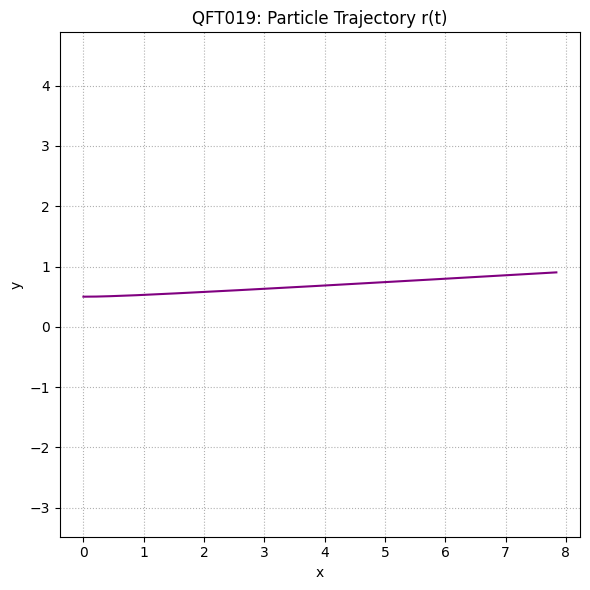

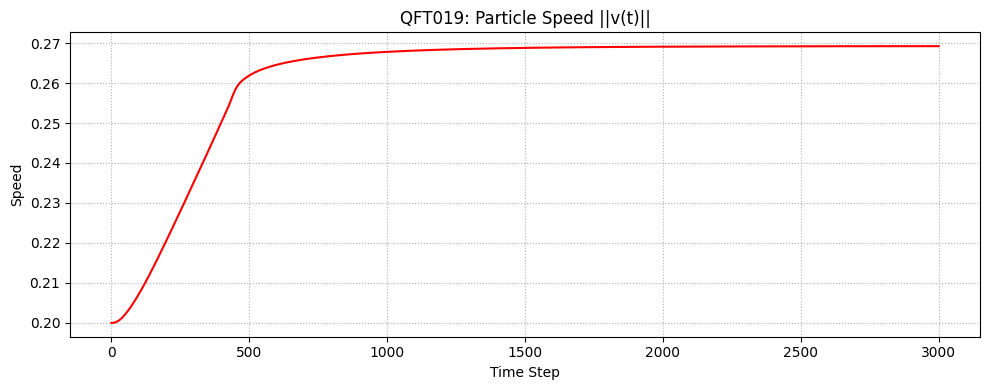

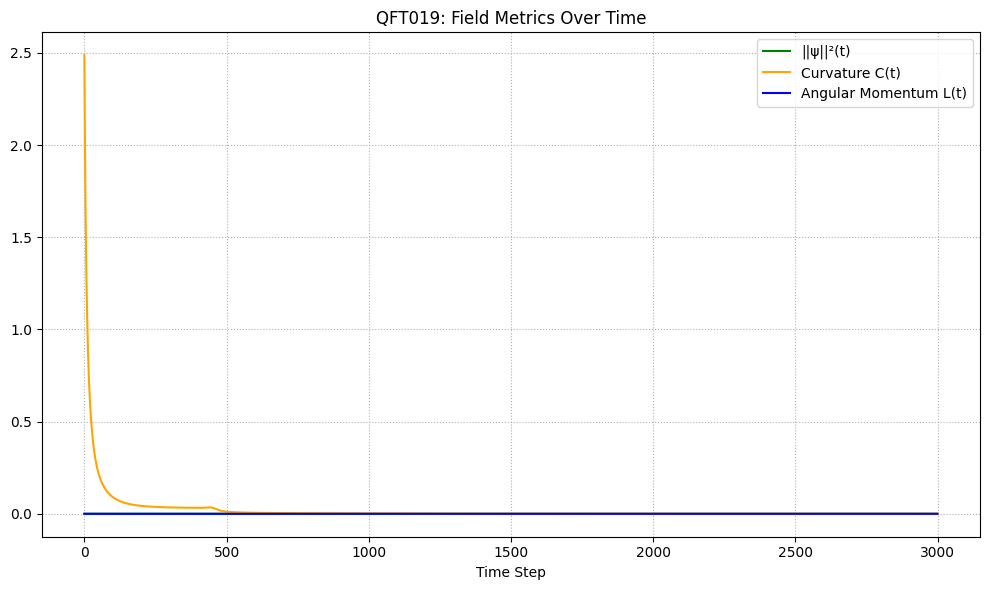

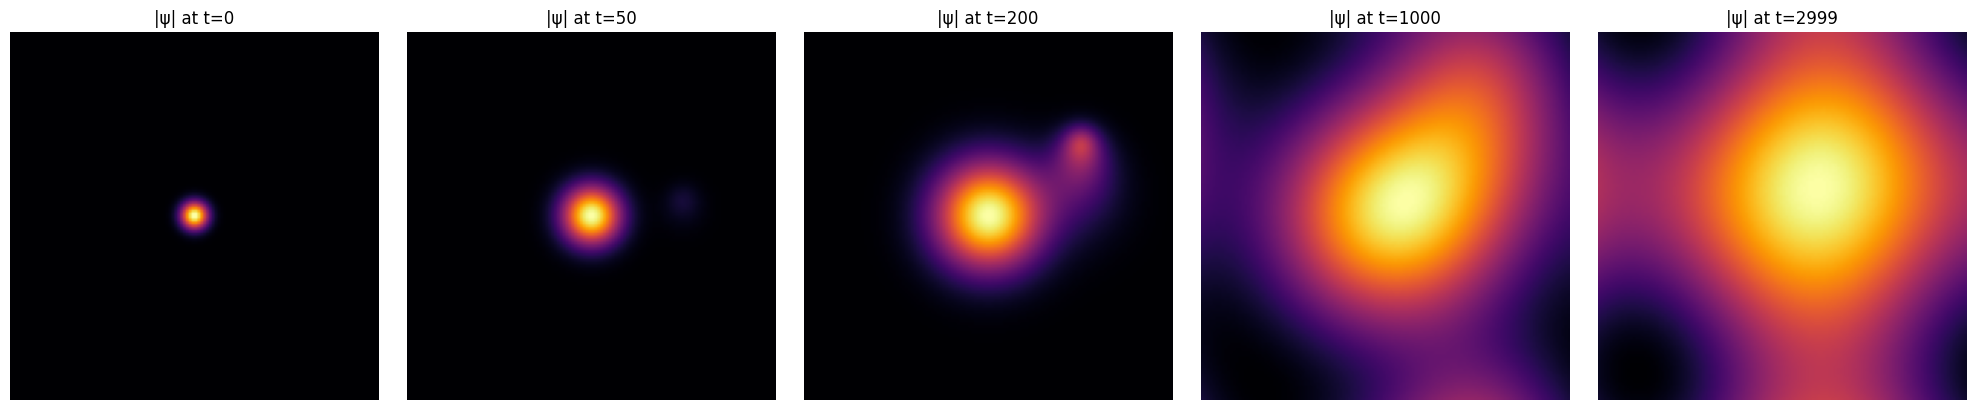

In [ ]:
# QFT019: Corrected Orbital Mechanics with Mass and Initial Velocity
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N_grid = 128
T = 3000
dt = 0.01
kappa = 0.1
gamma = 0.01
delta = 0.039
epsilon = 0.01
mass = 1.0

# Grid setup
x = np.linspace(-1, 1, N_grid)
y = np.linspace(-1, 1, N_grid)
X, Y = np.meshgrid(x, y, indexing='ij')
dx = x[1] - x[0]

# Initial field: fused attractor
def gaussian(x0, y0, sigma=0.05, amp=0.1):
    return amp * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))

psi = gaussian(0.0, 0.0).astype(np.complex128)

# Particle initialization
r = np.array([0.0, 0.5])
v = np.array([0.2, 0.0])  # initial tangential velocity
trajectory = [r.copy()]
velocity_track = [np.linalg.norm(v)]

# FFT Laplacian kernel
kx = np.fft.fftfreq(N_grid, d=dx) * 2 * np.pi
ky = np.fft.fftfreq(N_grid, d=dx) * 2 * np.pi
KX, KY = np.meshgrid(kx, ky, indexing='ij')
laplacian_kernel = -(KX**2 + KY**2)

# Trackers
norm_t = []
curvature_t = []
L_t = []
snapshots = {}

# Simulation loop
for t in range(T):
    # Gradient of |ψ|
    abs_psi = np.abs(psi)
    grad_x = (np.roll(abs_psi, -1, axis=0) - np.roll(abs_psi, 1, axis=0)) / (2 * dx)
    grad_y = (np.roll(abs_psi, -1, axis=1) - np.roll(abs_psi, 1, axis=1)) / (2 * dx)

    # Interpolate gradient at particle position
    i = int((r[0] + 1) / 2 * N_grid)
    j = int((r[1] + 1) / 2 * N_grid)
    i = np.clip(i, 1, N_grid - 2)
    j = np.clip(j, 1, N_grid - 2)
    grad_r = np.array([grad_x[i, j], grad_y[i, j]])

    # Update velocity and position
    v -= dt * grad_r / mass
    r += dt * v
    trajectory.append(r.copy())
    velocity_track.append(np.linalg.norm(v))

    # Source term: Gaussian centered at r(t)
    source = epsilon * np.exp(-((X - r[0])**2 + (Y - r[1])**2) / (2 * 0.05**2))

    # Curvature
    laplacian_psi = np.fft.ifft2(laplacian_kernel * np.fft.fft2(psi))
    curvature = np.sqrt(np.mean(np.abs(laplacian_psi)**2))
    curvature_t.append(curvature)

    # Angular momentum
    grad_psi_x = np.fft.ifft2(1j * KX * np.fft.fft2(psi))
    grad_psi_y = np.fft.ifft2(1j * KY * np.fft.fft2(psi))
    L_density = np.imag(np.conj(psi) * (X * grad_psi_y - Y * grad_psi_x))
    L = np.sum(L_density) * dx * dx
    L_t.append(L)

    # Norm
    norm = np.sum(np.abs(psi)**2) * dx * dx
    norm_t.append(norm)

    # HES PDE update
    nonlinear = delta * np.abs(psi)**2 * psi
    restoring = -kappa * psi
    rhs = psi + dt * (nonlinear + restoring + source)
    rhs_fft = np.fft.fft2(rhs)
    psi_fft = rhs_fft / (1 - dt * gamma * laplacian_kernel)
    psi = np.fft.ifft2(psi_fft)

    if t in [0, 50, 200, 1000, 2999]:
        snapshots[t] = np.abs(psi)

# Plot trajectory
trajectory = np.array(trajectory)
plt.figure(figsize=(6, 6))
plt.plot(trajectory[:, 0], trajectory[:, 1], color='purple')
plt.title('QFT019: Particle Trajectory r(t)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle=':')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Plot velocity
plt.figure(figsize=(10, 4))
plt.plot(velocity_track, color='red')
plt.title('QFT019: Particle Speed ||v(t)||')
plt.xlabel('Time Step')
plt.ylabel('Speed')
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

# Plot diagnostics
plt.figure(figsize=(10, 6))
plt.plot(norm_t, label='||ψ||²(t)', color='green')
plt.plot(curvature_t, label='Curvature C(t)', color='orange')
plt.plot(L_t, label='Angular Momentum L(t)', color='blue')
plt.title('QFT019: Field Metrics Over Time')
plt.xlabel('Time Step')
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

# Plot field snapshots
fig, axes = plt.subplots(1, len(snapshots), figsize=(20, 4))
for idx, (t_snap, field) in enumerate(snapshots.items()):
    axes[idx].imshow(field, cmap='inferno', origin='lower')
    axes[idx].set_title(f'|ψ| at t={t_snap}')
    axes[idx].axis('off')
plt.tight_layout()
plt.show()
